<a href="https://colab.research.google.com/github/Sgln24/flyrank-ml-internship-w1/blob/main/notebooks/03_working_with_the_full_release.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weeks 3+ — Working with the full release (~79M rows) without downloading 79M rows

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sgln24/flyrank-ml-internship-w1/blob/main/notebooks/03_working_with_the_full_release.ipynb?flush_cache=true)

Notebooks 01–02 used the small starter CSV that ships with this repo. Your lane and capstone work
run on the **full pseudonymized warehouse release**: ~17 months of daily search performance for
~70 clients, plus a query-level table. It is hosted as Parquet on Hugging Face, and the trick of
this notebook is that you **never download or load the whole thing** — DuckDB reads only the
columns and partitions your SQL touches.

By the end you will have:
1. Connected DuckDB to the hosted release and listed every table.
2. Pulled a **feature table you designed** (aggregates per content item) into pandas.
3. Trained a quick scikit-learn model on features you built from 79M rows — on a free Colab CPU.

**Before you start (one-time, ~2 minutes):**
1. Create a free [Hugging Face account](https://huggingface.co/join).
2. Open the dataset page ([`FlyRank/internship-warehouse`](https://huggingface.co/datasets/FlyRank/internship-warehouse)) and **request access** (instant after you accept the data-use terms). **Accept the terms in your browser first — the token below 401s until access is granted (usually instant).**
3. Create a **read** token at [Settings → Access Tokens](https://huggingface.co/settings/tokens). **Never paste the token into a code cell** — your repo is public; use the `getpass` prompt below (or Colab's 🔑 Secrets panel).


In [1]:
%pip -q install duckdb huggingface_hub


In [2]:
import os, getpass

# Token order: env var -> Colab Secret -> prompt (last resort).
# Use a Colab Secret named HF_TOKEN (the key panel on the left) so the prompt never
# fires: if Colab reconnects while a getpass prompt is open, the kernel waits on it
# forever ('Resuming execution...') and you have to restart the runtime.
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')


Paste your Hugging Face READ token (hf_...): ··········


## 1. Connect DuckDB to the release

DuckDB speaks `hf://` natively. The secret below authenticates every query; after that the
release behaves like a set of local tables.


In [3]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')


dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


That count over the daily fact touched **Parquet metadata, not data** — it finished in seconds
even though the table has ~79M rows. That is the whole workflow: push the heavy lifting into
DuckDB SQL, bring only small results into pandas.

## 2. Know your panel before you model it

History depth **differs per client** (an *unbalanced panel*). `dim_clients` tells you exactly
what each client has — check it before designing any time window.


In [4]:
clients = con.sql(f"""
    SELECT client_hash_id, access_profile, gsc_data_start, ga4_data_start
    FROM {TABLES['dim_clients']}
    ORDER BY gsc_data_start NULLS LAST
""").df()

print('clients with 12+ months of GSC history:',
      (clients['gsc_data_start'] <= clients['gsc_data_start'].dropna().max() - __import__('pandas').Timedelta(days=365)).sum())
clients.head(10)


clients with 12+ months of GSC history: 4


,client_hash_id,access_profile,gsc_data_start,ga4_data_start
0,client_9958f0a7ae1df715,gsc_and_ga4,2025-01-27,2025-10-29
1,client_ff644d8251367cbb,gsc_and_ga4,2025-01-27,2025-10-29
2,client_73cda7b4e4f265ea,gsc_and_ga4,2025-02-11,2026-03-24
3,client_fef1a8f436438636,gsc_and_ga4,2025-03-11,2026-03-06
4,client_62f4a7e64f5e0096,gsc_only,2025-06-07,NaT
5,client_b10cb2997d0c7c86,gsc_and_ga4,2025-06-18,2025-11-15
6,client_65de48885f4ef01b,gsc_and_ga4,2025-06-21,2026-02-19
7,client_c182d11e4862a37d,gsc_and_ga4,2025-06-21,2026-02-20
8,client_3197e6291363b4db,gsc_and_ga4,2025-06-29,2025-11-09
9,client_625b6439094e23e4,gsc_and_ga4,2025-07-01,2026-02-19


In [5]:
con.sql("SHOW TABLES").df()

con.sql(f"""
SELECT *
FROM {TABLES['dim_content']}
LIMIT 1
""").df()


con.sql(f"""
SELECT *
FROM {TABLES['fact_daily']}
LIMIT 1
""").df()


con.sql(f"""
SELECT *
FROM {TABLES['fact_query_90d']}
LIMIT 1
""").df()


,client_hash_id,content_hash_id,query_hash_id,query_char_count,query_token_count,window_start,window_end,impressions_90d,clicks_90d,impressions_last30,...,impressions_prev30,clicks_prev30,avg_position_90d,avg_position_last30,avg_position_prev30,content_total_impressions_90d,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_58b1b001f839d699,17,3,2026-04-02,2026-06-30,11,0,0,...,11,0,10.818182,NaN,10.818182,1466,14,32,0.043656,0.725102


In [6]:
con.sql(f"""
SELECT *
FROM {TABLES['dim_content']}
LIMIT 1
""").df()

,client_hash_id,content_hash_id,keyword_hash_id,url_hash_id,keyword_char_count,keyword_token_count,url_char_count,content_created_date,content_updated_date,content_type,...,category_count,keyword_created_date,provider_used,model_used,char_count,word_count,last_optimized_date,optimization_eligible_date,is_published,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,keyword_e754999ab88dd9f2,url_d6091f18cf628794,22,4,108,2026-05-30,2026-07-01,keyword article,...,3,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15682,2555,NaT,NaT,True,False


## 3. Build features with SQL, not with RAM

The pattern for every lane: **aggregate per content item inside DuckDB**, then hand the small
result to pandas/sklearn. Here: momentum features from the last 60 days of the panel.

**This is the heaviest cell in the notebook — expect 2–6 minutes on Colab.** It downloads ~2 months of column data over the network (RAM stays tiny; that's the point). If it runs past ~10 minutes or errors with `HTTP 429`, re-run this section against `TABLES['fact_daily_sample']` and save the full table for your final pass.


In [7]:
features = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}
    ),
    windowed AS (
        SELECT f.client_hash_id, f.content_hash_id,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last30,
               SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev30,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_clicks ELSE 0 END)      AS clk_last30,
               AVG(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_avg_position END)       AS pos_last30
        FROM {TABLES['fact_daily']} f, bounds b
        WHERE f.report_date > b.end_d - INTERVAL 60 DAY
        GROUP BY 1, 2
        HAVING imp_prev30 >= 100
    )
    SELECT * FROM windowed
""").df()

print(f'{len(features):,} content items with enough history')
features.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

111,247 content items with enough history


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30
0,client_62f4a7e64f5e0096,content_0dac238195631de4,219.0,251.0,0.0,3.468159
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,995.0,4786.0,2.0,25.024091
2,client_62f4a7e64f5e0096,content_332f337f995e9781,103.0,177.0,0.0,18.600206
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,736.0,1518.0,2.0,9.526655
4,client_62f4a7e64f5e0096,content_742939be32c206d2,269.0,335.0,3.0,7.904483


## 4. Add query-level signals

`fact_content_query_90d` describes **how a page earns its impressions**: across how many
distinct queries, how concentrated, how much sits in the rare/anonymized tail. One page ranking
for 40 queries is a different animal from one page ranking for 2.


In [8]:
qsignals = con.sql(f"""
    SELECT content_hash_id,
           ANY_VALUE(content_visible_query_count)     AS visible_queries,
           ANY_VALUE(rare_impressions_share)          AS rare_share,
           ANY_VALUE(anonymized_impressions_share)    AS anon_share,
           MAX(impressions_90d)                       AS top_query_impressions,
           SUM(impressions_90d)                       AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
""").df()

qsignals['top_query_share'] = qsignals['top_query_impressions'] / qsignals['kept_impressions']
data = features.merge(qsignals, on='content_hash_id', how='left')
print(f'joined: {len(data):,} rows')
data.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

joined: 111,247 rows


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share
0,client_62f4a7e64f5e0096,content_0dac238195631de4,219.0,251.0,0.0,3.468159,15.0,0.144623,0.665019,79.0,308.0,0.256494
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,995.0,4786.0,2.0,25.024091,101.0,0.037423,0.178737,15557.0,18432.0,0.844021
2,client_62f4a7e64f5e0096,content_332f337f995e9781,103.0,177.0,0.0,18.600206,3.0,0.215054,0.623656,25.0,60.0,0.416667
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,736.0,1518.0,2.0,9.526655,16.0,0.032740,0.717915,473.0,952.0,0.496849
4,client_62f4a7e64f5e0096,content_742939be32c206d2,269.0,335.0,3.0,7.904483,8.0,0.224066,0.630705,30.0,140.0,0.214286


## 5. A first honest model

Same shape as notebook 02: define a label, hold out data, compare against a dumb baseline.
Label: *did impressions decline by more than 20% month-over-month?* — built only from columns
that exist **before** the window we predict. (Momentum features from the last 30 days predicting
a label defined on those same 30 days would be leakage — so here the features come from the
prev-30 window and query-mix, and the label from the last-30 outcome.)


In [9]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

data['is_declining'] = (data['imp_last30'] < 0.8 * data['imp_prev30']).astype(int)

feature_cols = ['imp_prev30', 'visible_queries', 'rare_share', 'anon_share', 'top_query_share']
model_data = data.dropna(subset=feature_cols)
X, y = model_data[feature_cols], model_data['is_declining']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_tr, y_tr)

print(f'base rate (always predict majority): {max(y_te.mean(), 1 - y_te.mean()):.3f}')
print(classification_report(y_te, model.predict(X_te), digits=3))


base rate (always predict majority): 0.633
              precision    recall  f1-score   support

           0      0.542     0.339     0.417      9389
           1      0.685     0.834     0.752     16162

    accuracy                          0.652     25551
   macro avg      0.614     0.586     0.585     25551
weighted avg      0.632     0.652     0.629     25551



In [10]:
dataset = con.sql(f"""
SELECT
    f.client_hash_id,
    f.content_hash_id,
    d.content_type
FROM {TABLES['fact_query_90d']} AS f
JOIN {TABLES['dim_content']} AS d
    ON f.client_hash_id = d.client_hash_id
   AND f.content_hash_id = d.content_hash_id
LIMIT 5
""").df()

dataset.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,content_hash_id,content_type
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,keyword article
1,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,keyword article
2,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,keyword article
3,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,keyword article
4,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,keyword article


In [11]:
con.sql(f"""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT content_hash_id) AS unique_content,
    COUNT(DISTINCT (client_hash_id, content_hash_id)) AS unique_client_content
FROM {TABLES['fact_query_90d']}
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,unique_content,unique_client_content
0,2414248,133852,133852


In [12]:
data.shape
data.info()
data.describe().T
data.isna().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111247 entries, 0 to 111246
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   client_hash_id         111247 non-null  object 
 1   content_hash_id        111247 non-null  object 
 2   imp_last30             111247 non-null  float64
 3   imp_prev30             111247 non-null  float64
 4   clk_last30             111247 non-null  float64
 5   pos_last30             110087 non-null  float64
 6   visible_queries        102203 non-null  float64
 7   rare_share             102203 non-null  float64
 8   anon_share             102203 non-null  float64
 9   top_query_impressions  102203 non-null  float64
 10  kept_impressions       102203 non-null  float64
 11  top_query_share        102203 non-null  float64
 12  is_declining           111247 non-null  int64  
dtypes: float64(10), int64(1), object(2)
memory usage: 11.0+ MB


,0
top_query_share,9044
top_query_impressions,9044
anon_share,9044
rare_share,9044
visible_queries,9044
kept_impressions,9044
pos_last30,1160
clk_last30,0
content_hash_id,0
client_hash_id,0


In [13]:
numeric_cols =data.select_dtypes(include="number")

corr = numeric_cols.corr(numeric_only=True)

corr

,imp_last30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share,is_declining
imp_last30,1.000000,0.820592,0.727408,-0.156073,0.719672,-0.175092,-0.012736,0.422395,0.789026,-0.169156,-0.154925
imp_prev30,0.820592,1.000000,0.540646,-0.145896,0.769354,-0.215966,-0.012108,0.513061,0.862808,-0.190197,-0.015488
clk_last30,0.727408,0.540646,1.000000,-0.143920,0.561343,-0.131728,0.035223,0.177188,0.445229,-0.127877,-0.135770
pos_last30,-0.156073,-0.145896,-0.143920,1.000000,-0.111204,0.535314,-0.547610,-0.054214,-0.108779,0.013717,0.184887
visible_queries,0.719672,0.769354,0.561343,-0.111204,1.000000,-0.165436,-0.080495,0.223182,0.618660,-0.294795,-0.025133
rare_share,-0.175092,-0.215966,-0.131728,0.535314,-0.165436,1.000000,-0.580257,-0.091842,-0.159614,0.092573,-0.015981
anon_share,-0.012736,-0.012108,0.035223,-0.547610,-0.080495,-0.580257,1.000000,-0.125316,-0.126471,0.082406,0.031529
top_query_impressions,0.422395,0.513061,0.177188,-0.054214,0.223182,-0.091842,-0.125316,1.000000,0.740813,0.029688,-0.015251
kept_impressions,0.789026,0.862808,0.445229,-0.108779,0.618660,-0.159614,-0.126471,0.740813,1.000000,-0.110840,-0.039147
top_query_share,-0.169156,-0.190197,-0.127877,0.013717,-0.294795,0.092573,0.082406,0.029688,-0.110840,1.000000,0.061365


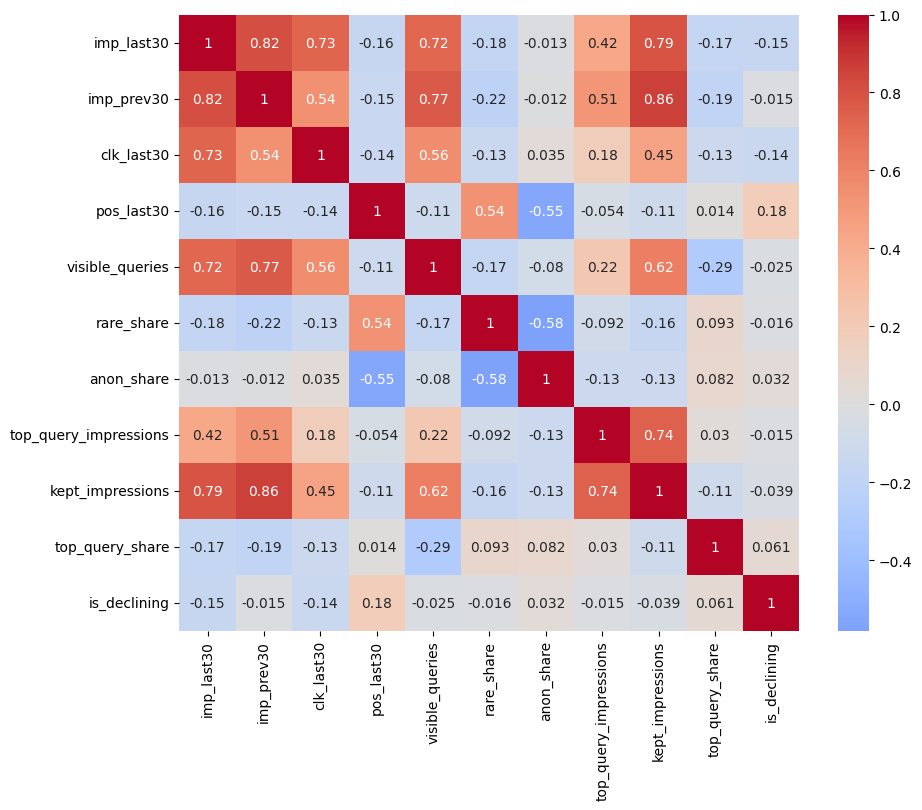

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.show()

In [15]:
content_df = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    word_count,
    char_count,
    category_count,
    content_type,
    keyword_token_count,
    keyword_char_count
FROM {TABLES['dim_content']}
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [16]:
analysis_df_v2 = data.merge(
    content_df,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

In [17]:
analysis_df_v2.shape
analysis_df_v2.info()
analysis_df_v2.isna().sum()
analysis_df_v2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111247 entries, 0 to 111246
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   client_hash_id         111247 non-null  object 
 1   content_hash_id        111247 non-null  object 
 2   imp_last30             111247 non-null  float64
 3   imp_prev30             111247 non-null  float64
 4   clk_last30             111247 non-null  float64
 5   pos_last30             110087 non-null  float64
 6   visible_queries        102203 non-null  float64
 7   rare_share             102203 non-null  float64
 8   anon_share             102203 non-null  float64
 9   top_query_impressions  102203 non-null  float64
 10  kept_impressions       102203 non-null  float64
 11  top_query_share        102203 non-null  float64
 12  is_declining           111247 non-null  int64  
 13  word_count             87202 non-null   Int64  
 14  char_count             87202 non-nul

,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share,is_declining,word_count,char_count,category_count,content_type,keyword_token_count,keyword_char_count
0,client_62f4a7e64f5e0096,content_0dac238195631de4,219.0,251.0,0.0,3.468159,15.0,0.144623,0.665019,79.0,308.0,0.256494,0,<NA>,<NA>,7,keyword article,9,54
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,995.0,4786.0,2.0,25.024091,101.0,0.037423,0.178737,15557.0,18432.0,0.844021,1,2938,19689,4,keyword article,8,45
2,client_62f4a7e64f5e0096,content_332f337f995e9781,103.0,177.0,0.0,18.600206,3.0,0.215054,0.623656,25.0,60.0,0.416667,1,2434,15467,1,keyword article,9,49
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,736.0,1518.0,2.0,9.526655,16.0,0.032740,0.717915,473.0,952.0,0.496849,1,2787,17366,5,keyword article,8,43
4,client_62f4a7e64f5e0096,content_742939be32c206d2,269.0,335.0,3.0,7.904483,8.0,0.224066,0.630705,30.0,140.0,0.214286,0,<NA>,<NA>,4,keyword article,9,43


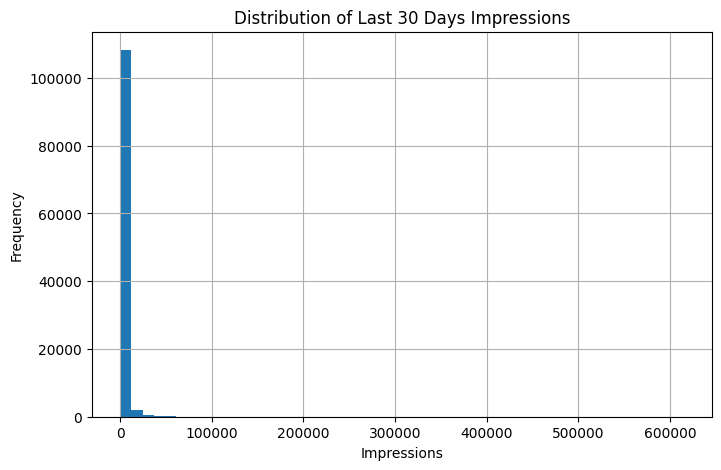

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

analysis_df_v2["imp_last30"].hist(bins=50)

plt.title("Distribution of Last 30 Days Impressions")
plt.xlabel("Impressions")
plt.ylabel("Frequency")

plt.show()

In [19]:
analysis_df_v2["imp_last30"].describe()

,imp_last30
count,111247.000000
mean,1837.639595
std,6770.709487
min,0.000000
25%,131.000000
50%,388.000000
75%,1292.000000
max,615012.000000


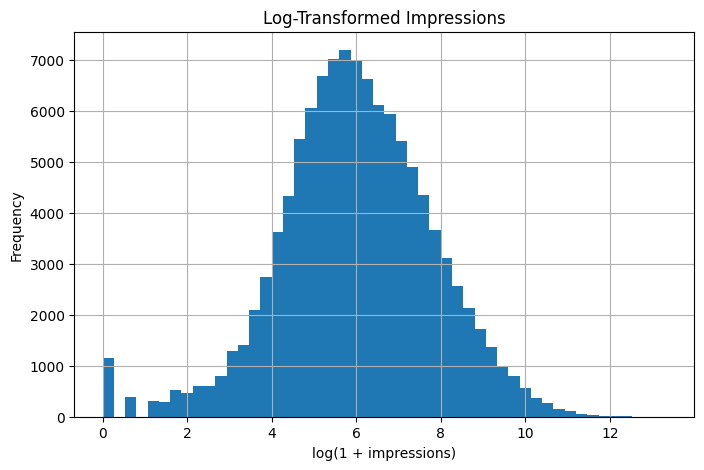

In [20]:
import numpy as np
import matplotlib.pyplot as plt

analysis_df_v2["log_imp_last30"] = np.log1p(analysis_df_v2["imp_last30"])

plt.figure(figsize=(8,5))
analysis_df_v2["log_imp_last30"].hist(bins=50)

plt.title("Log-Transformed Impressions")
plt.xlabel("log(1 + impressions)")
plt.ylabel("Frequency")

plt.show()

In [21]:
analysis_df_v2["log_imp_last30"].describe()

,log_imp_last30
count,111247.000000
mean,5.975236
std,1.827259
min,0.000000
25%,4.882802
50%,5.963579
75%,7.164720
max,13.329399


In [22]:
candidate_features = [
    "pos_last30",
    "visible_queries",
    "rare_share",
    "anon_share",
    "top_query_share",
    "word_count",
    "char_count",
    "category_count",
    "keyword_token_count",
    "keyword_char_count"
]

analysis_df_v2[candidate_features + ["log_imp_last30"]].corr(numeric_only=True)["log_imp_last30"].sort_values(ascending=False)

,log_imp_last30
log_imp_last30,1.000000
visible_queries,0.453270
anon_share,0.178646
keyword_char_count,0.048101
keyword_token_count,0.030473
category_count,0.026429
word_count,-0.044647
char_count,-0.068014
pos_last30,-0.371334
rare_share,-0.439970


In [23]:
analysis_df_v2[
    [
        "word_count",
        "char_count",
        "visible_queries",
        "rare_share",
        "anon_share",
        "top_query_share",
        "pos_last30"
    ]
].isna().mean() * 100

,0
word_count,21.614066
char_count,21.614066
visible_queries,8.129657
rare_share,8.129657
anon_share,8.129657
top_query_share,8.129657
pos_last30,1.042725


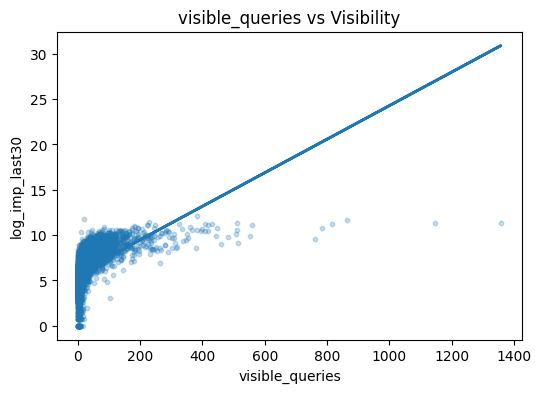

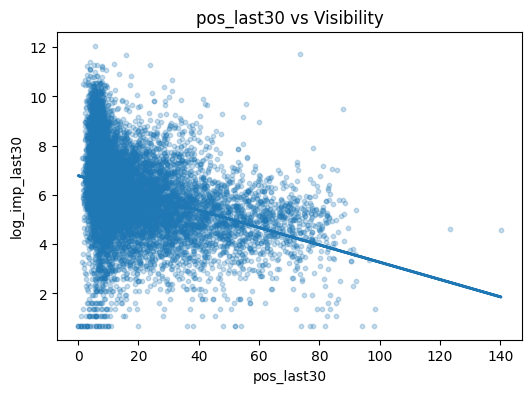

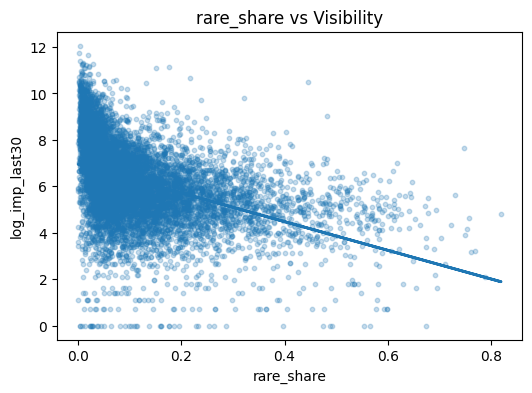

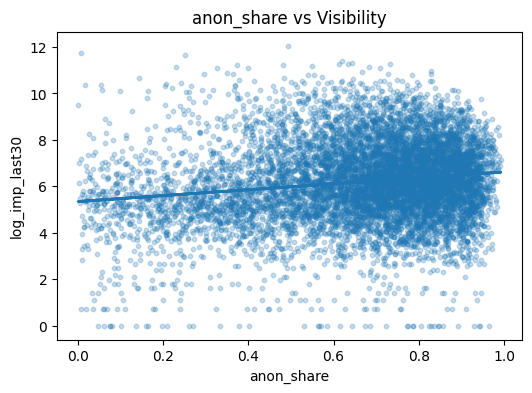

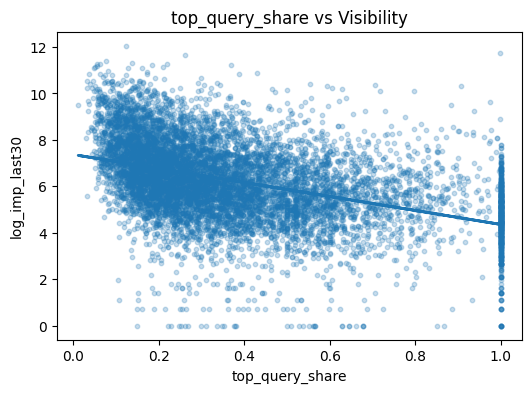

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

search_features = [
    "visible_queries",
    "pos_last30",
    "rare_share",
    "anon_share",
    "top_query_share"
]
sample_df = analysis_df_v2.sample(
    n=10000,
    random_state=42
)

for feature in search_features:

    # إزالة الـ Missing
    temp = sample_df[[feature, "log_imp_last30"]].dropna()

    plt.figure(figsize=(6,4))

    plt.scatter(
        temp[feature],
        temp["log_imp_last30"],
        alpha=0.25,
        s=10
    )

    # Trend Line
    z = np.polyfit(temp[feature], temp["log_imp_last30"], 1)
    p = np.poly1d(z)

    plt.plot(
        temp[feature],
        p(temp[feature]),
        linewidth=2
    )

    plt.title(f"{feature} vs Visibility")
    plt.xlabel(feature)
    plt.ylabel("log_imp_last30")

    plt.show()

In [25]:
#define target and features

search_features = [
    "visible_queries",
    "pos_last30",
    "rare_share",
    "anon_share",
    "top_query_share"
]

X = analysis_df_v2[search_features]

y = analysis_df_v2["log_imp_last30"]

In [26]:
#simple train/split , will be changed later for data leakage
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [28]:
y_pred = rf.predict(X_test)

In [29]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("R² :", round(r2,4))
print("MAE:", round(mae,4))
print("RMSE:", round(rmse,4))

R² : 0.77
MAE: 0.6424
RMSE: 0.882


In [30]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": search_features,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,visible_queries,0.514162
1,pos_last30,0.272258
3,anon_share,0.090217
2,rare_share,0.077897
4,top_query_share,0.045467


In [33]:
content_features = [
    "word_count",
    "char_count",
    "category_count",
    "keyword_token_count",
    "keyword_char_count"
]
analysis_df_v2[content_features].isna().sum()
analysis_df_v2[content_features].describe().T

corr = analysis_df_v2[
    content_features + ["log_imp_last30"]
].corr()

corr["log_imp_last30"].sort_values(ascending=False)

,log_imp_last30
log_imp_last30,1.000000
keyword_char_count,0.048101
keyword_token_count,0.030473
category_count,0.026429
word_count,-0.044647
char_count,-0.068014


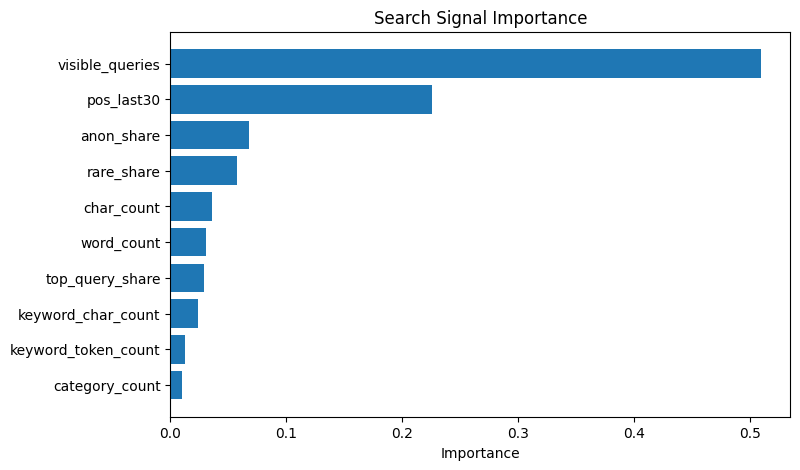

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Search Signal Importance")

plt.xlabel("Importance")

plt.show()


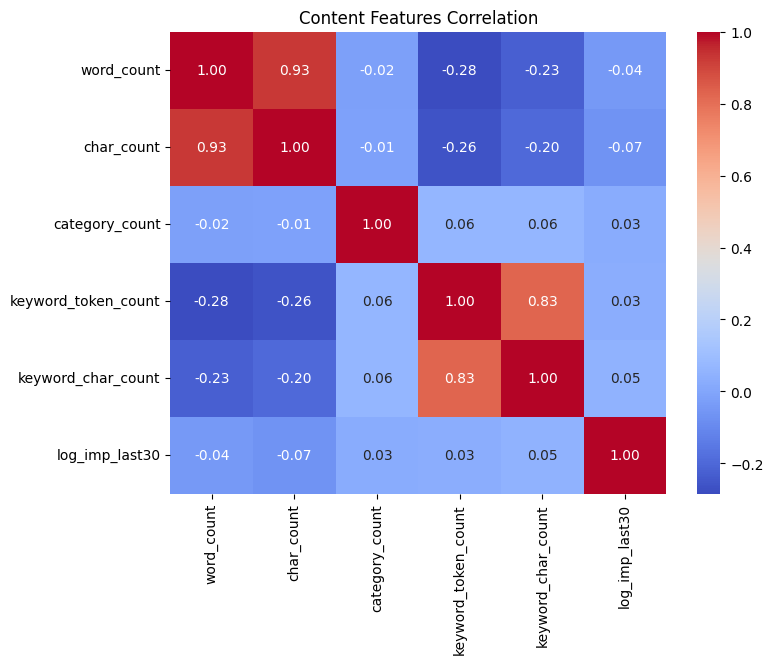

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    analysis_df_v2[
        content_features + ["log_imp_last30"]
    ].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Content Features Correlation")

plt.show()

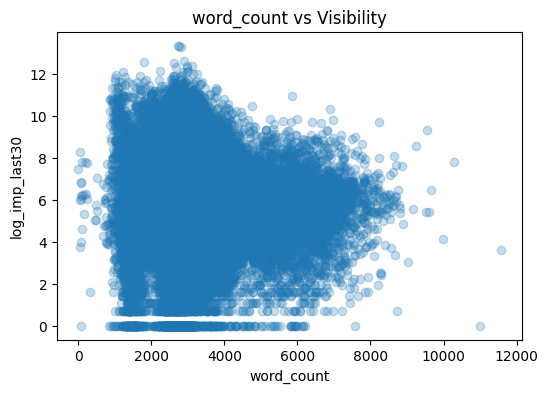

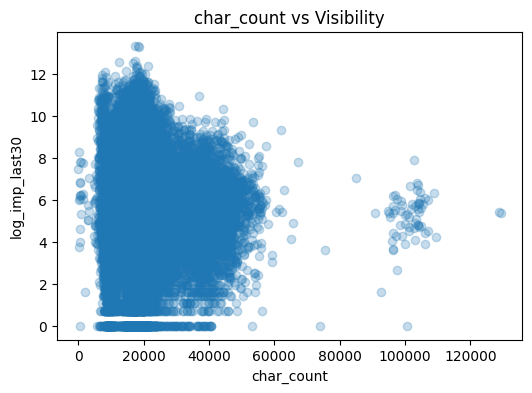

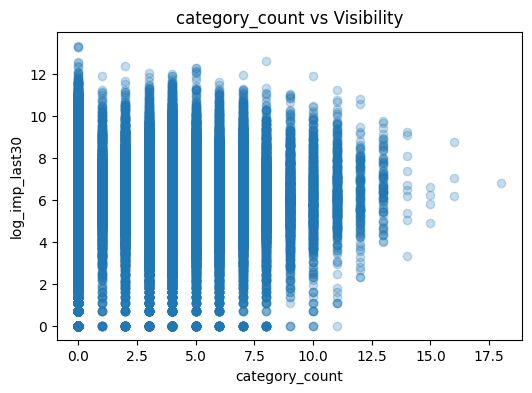

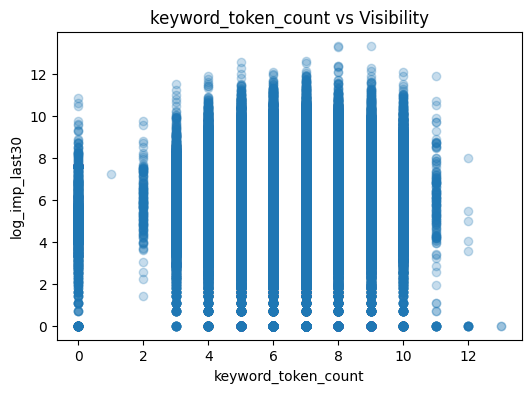

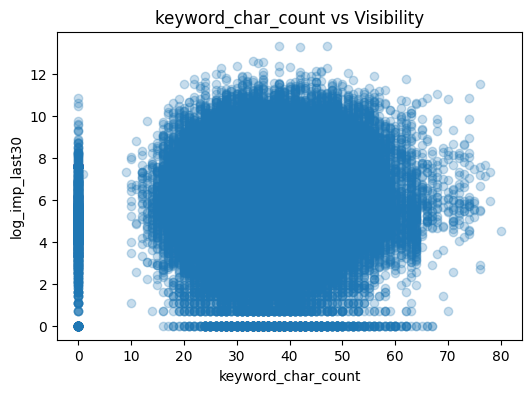

In [36]:
import matplotlib.pyplot as plt

for feature in content_features:

    plt.figure(figsize=(6,4))

    plt.scatter(
        analysis_df_v2[feature],
        analysis_df_v2["log_imp_last30"],
        alpha=0.25
    )

    plt.xlabel(feature)

    plt.ylabel("log_imp_last30")

    plt.title(f"{feature} vs Visibility")

    plt.show()

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

content_features = [
    "word_count",
    "char_count",
    "category_count",
    "keyword_token_count",
    "keyword_char_count"
]

X = analysis_df_v2[content_features]
y = analysis_df_v2["log_imp_last30"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf_content = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_content.fit(X_train, y_train)

y_pred = rf_content.predict(X_test)

print("R² :", round(r2_score(y_test, y_pred),4))
print("MAE:", round(mean_absolute_error(y_test, y_pred),4))
print("RMSE:", round(root_mean_squared_error(y_test, y_pred),4))

R² : 0.0819
MAE: 1.3389
RMSE: 1.762


               Feature  Importance
1           char_count    0.404313
0           word_count    0.285009
4   keyword_char_count    0.165240
3  keyword_token_count    0.079671
2       category_count    0.065768


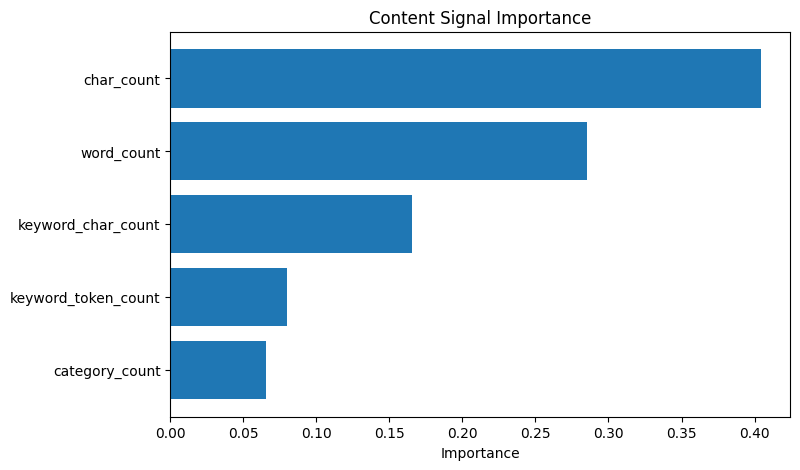

In [38]:
importance = (
    pd.DataFrame({
        "Feature": content_features,
        "Importance": rf_content.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

print(importance)

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Content Signal Importance")
plt.xlabel("Importance")
plt.show()

In [39]:
search_features = [
    "visible_queries",
    "pos_last30",
    "rare_share",
    "anon_share",
    "top_query_share"
]

content_features = [
    "word_count",
    "char_count",
    "category_count",
    "keyword_token_count",
    "keyword_char_count"
]

all_features = search_features + content_features

X = analysis_df_v2[all_features]
y = analysis_df_v2["log_imp_last30"]

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [41]:
from sklearn.ensemble import RandomForestRegressor

rf_final = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [42]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

y_pred = rf_final.predict(X_test)

print("R² :", round(r2_score(y_test, y_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 4))
print("RMSE:", round(root_mean_squared_error(y_test, y_pred), 4))

R² : 0.7884
MAE: 0.613
RMSE: 0.846


In [43]:
import pandas as pd
import matplotlib.pyplot as plt

importance = (
    pd.DataFrame({
        "Feature": all_features,
        "Importance": rf_final.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

print(importance)

               Feature  Importance
0      visible_queries    0.509090
1           pos_last30    0.225259
3           anon_share    0.067397
2           rare_share    0.057042
6           char_count    0.035696
5           word_count    0.030441
4      top_query_share    0.028906
9   keyword_char_count    0.024040
8  keyword_token_count    0.012363
7       category_count    0.009767


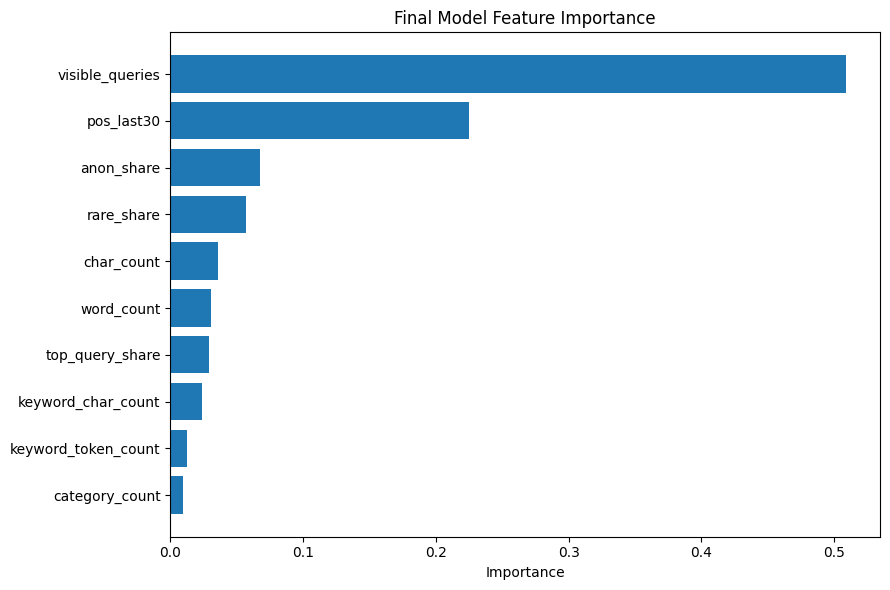

In [44]:
plt.figure(figsize=(9,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Final Model Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [45]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

# نفس الـ Split المستخدم في الـ Final Model
dummy = DummyRegressor(strategy="mean")

dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

print("Dummy Regressor Results")
print("-----------------------")
print("R² :", round(r2_score(y_test, dummy_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, dummy_pred), 4))
print("RMSE:", round(root_mean_squared_error(y_test, dummy_pred), 4))

Dummy Regressor Results
-----------------------
R² : -0.0
MAE: 1.4201
RMSE: 1.839


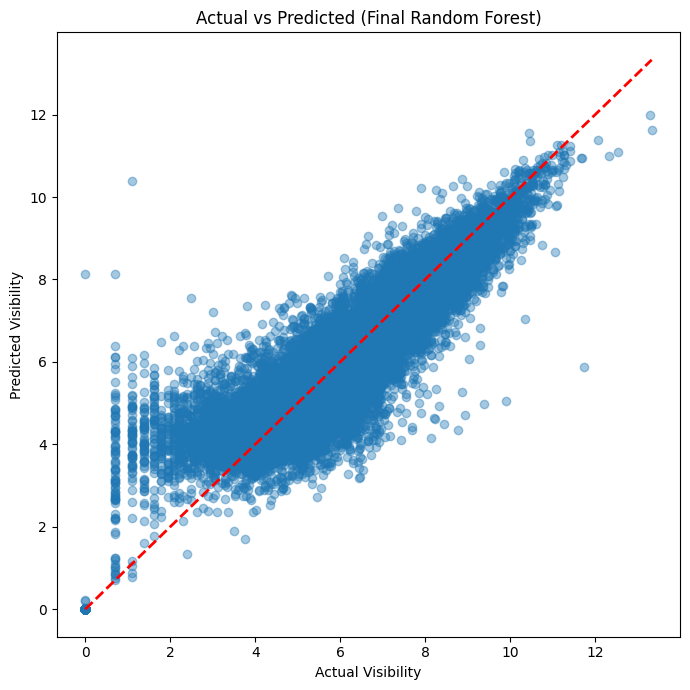

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

# خط التوقع المثالي
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Visibility")
plt.ylabel("Predicted Visibility")
plt.title("Actual vs Predicted (Final Random Forest)")

plt.tight_layout()
plt.show()

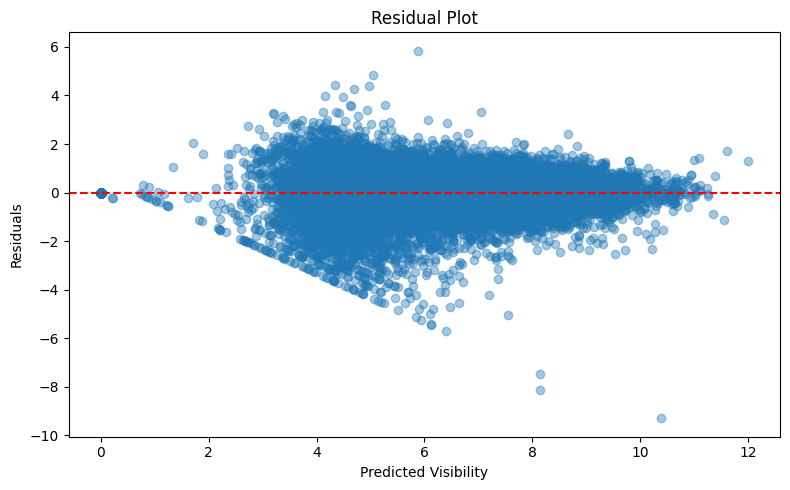

In [47]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Visibility")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

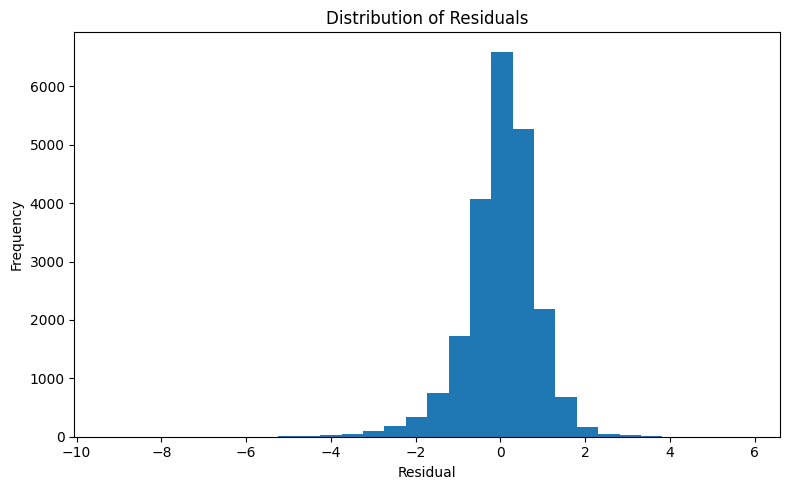

In [48]:
plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=30
)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Whatever number you just got: interrogate it before you believe it. Which feature carries the
signal? Does it survive a per-client split (train on some clients, test on others)? That
question — *does it generalize across clients?* — is exactly what separates a capstone-grade
result from a lucky split.

## Your turn

1. Re-run section 3 with a **90-day** window and a `HAVING` threshold of your choice.
2. Add one feature you believe in (position volatility? weekend share? query concentration?).
3. Replace the random split with **GroupShuffleSplit on `client_hash_id`** and compare.

## Working locally instead

```python
from huggingface_hub import snapshot_download
path = snapshot_download(repo_id='FlyRank/internship-warehouse', repo_type='dataset',
                         allow_patterns=['dim_*.parquet', 'fact_content_query_90d.parquet',
                                         'fact_content_daily_performance/month=2026-0*/*.parquet'])
```
Then point `REL` at that local path. Download only the month partitions you need — the
`allow_patterns` filter above is the whole trick.

---

**Where this fits:** every lane brief assumes you can produce per-content feature tables like
the one you just built. The lane datasets under the `lanes` HF repo are pre-cut examples of
exactly this pattern — but for the capstone, features you engineered yourself from the full
release beat any pre-cut file.
